This notebook is used for testing the trained segmentation model YOLOv8 on synthetic images generated with StyleGAN2-ADA and Pix2Pix architectures.

# IMPORTS

In [ ]:
# YOLOv8 package
!pip install ultralytics -q
!pip install pytorch-fid -q

import torch
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image

# Import Data Inputs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1HKCXBZcltonnDdbjtDT6RQD9ZcrGBnyj -O ./data/   # Trained weights
!gdown --folder https://drive.google.com/drive/folders/1vhftTxn0GGuwGepLNMtgdbJ0qGeXz4Lh -O ./data/   # real images dataset

## path config
DATA_DIR = '/kaggle/working/data'
WORK_DIR = '/kaggle/working/EVAL_IMAGES'

# output folders
os.makedirs(os.path.join(WORK_DIR, 'eval_real'), exist_ok=True)
os.makedirs(os.path.join(WORK_DIR, 'eval_pix2pix'), exist_ok=True)
os.makedirs(os.path.join(WORK_DIR, 'eval_stylegan_1'), exist_ok=True)
os.makedirs(os.path.join(WORK_DIR, 'eval_stylegan_07'), exist_ok=True)

# Installing SyleGAN2-ADA repo
!pip install ninja
!pip install opensimplex

if not os.path.isdir("stylegan2-ada-pytorch"):
    !git clone https://github.com/dvschultz/stylegan2-ada-pytorch

# Cloning repo RealESRGAN
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
!pip install basicsr facexlib gfpgan
!pip install -r requirements.txt
!python setup.py develop

# pix2pix repo cloning and requirement.txt install
%cd /kaggle/working
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
!pip install dominate visdom wandb


# UTILS

In [ ]:
# VERSION COMPATIBILITY PATCHES for StyleGAN2
import os

%cd /kaggle/working/stylegan2-ada-pytorch

# Enabling PyTorch functions. Disabling old NVIDIA methods.
!sed -i 's/enabled = True/enabled = False/g' torch_utils/ops/conv2d_gradfix.py
!sed -i 's/enabled = True/enabled = False/g' torch_utils/ops/grid_sample_gradfix.py

!sed -i 's/super().__init__(dataset)/super().__init__()/g' torch_utils/misc.py

# Disabling native C++ plugins (they don't work) and forcing PyTorch usage
files_to_patch = [
    'torch_utils/ops/bias_act.py',
    'torch_utils/ops/upfirdn2d.py'
]

for filename in files_to_patch:
    with open(filename, 'r') as f:
        code = f.read()

    if 'def _init():\n    return False' not in code:
        code = code.replace('def _init():', 'def _init():\n    return False\n')

    with open(filename, 'w') as f:
        f.write(code)

print("StyleGAN2 compatibility patch applied.")

#----------------------------------------------------
# Torchvision error FIX for RealESRGAN
import torchvision
import torch

!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py
print("Torchvision fix applied.")

print("Patches applied!")

# DATA PROCESSING

First off, we crop our real images from our dataset to 512x512px.

In [ ]:
import os
import zipfile
import cv2

## PATH CONFIG
ZIP_FILE = '/kaggle/working/data/EVAL/Reals.zip'
out_reals = '/kaggle/working/EVAL_IMAGES/eval_real/'

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(out_reals)

img_path = os.path.join(out_reals, 'Reals')
image_files = [f for f in os.listdir(img_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
print(f"{len(image_files)} images found.")

## CROPPING
print("Cropping to 512x512...")

n_cropped = 0

for file_name in image_files:
    file_path = os.path.join(img_path, file_name)
    
    img = cv2.imread(file_path)
    
    if img is None:
        continue
        
    h, w, c = img.shape

    left = (w - 512) // 2
    right = left + 512
    
    img_cropped = img[:, left:right]  # only crops width of the images
    
    cv2.imwrite(file_path, img_cropped)
    n_cropped += 1

print(f"{n_cropped} images cropped!")

_______________
**StyleGAN2 generation and upscaling**
\
We'll try using two different truncation parameters to improve the dataset variance. We'll try with 0.7 and 1.

In [ ]:
#### StyleGAN2, trunc = 0.7
import os

## PATH CONFIG
STYLEGAN_WEIGHTS = '/kaggle/working/data/WEIGHTS/styleGAN2_FID32weights.pkl'
ESRGAN_WEIGHTS = '/kaggle/working/data/WEIGHTS/realESRGAN_15Kiter_weights.pth'

STYLEGAN_REPO_DIR = '/kaggle/working/stylegan2-ada-pytorch'
ESRGAN_REPO_DIR = '/kaggle/working/Real-ESRGAN'

STYLEGAN_OUT_DIR = '/kaggle/working/stylegan_256_generate07'
FINAL_OUT_DIR = '/kaggle/working/EVAL_IMAGES/eval_stylegan_07'

os.makedirs(STYLEGAN_OUT_DIR, exist_ok=True)

## STYLEGAN2 GENERATION
%cd {STYLEGAN_REPO_DIR}

print("Generating 380 StyleGAN2 images, trunc = 0.7...")

!python generate.py \
    --network={STYLEGAN_WEIGHTS} \
    --seeds=1-380 \
    --trunc=0.7 \
    --outdir={STYLEGAN_OUT_DIR}

print(f"\n✅ 380 synthetic images (256x256px) generated in: {STYLEGAN_OUT_DIR}")

#------------------------------------
# UPSCALING WITH RealESRGAN
%cd {ESRGAN_REPO_DIR}

print("Upscaling from 256px to 512px...")

!python inference_realesrgan.py \
    -n RealESRGAN_x2plus \
    -i {STYLEGAN_OUT_DIR} \
    -o {FINAL_OUT_DIR} \
    --model_path {ESRGAN_WEIGHTS} \
    --outscale 2 \
    --ext auto

print(f"Images ready in: {FINAL_OUT_DIR}")

In [ ]:
#### StyleGAN2, trunc = 1
import os

## PATH CONFIG
STYLEGAN_OUT_DIR = '/kaggle/working/stylegan_256_generate1'
FINAL_OUT_DIR = '/kaggle/working/EVAL_IMAGES/eval_stylegan_1'

os.makedirs(STYLEGAN_OUT_DIR, exist_ok=True)

## STYLEGAN2 GENERATION
%cd {STYLEGAN_REPO_DIR}

print("Generating 380 StyleGAN2 images, trunc = 1...")

!python generate.py \
    --network={STYLEGAN_WEIGHTS} \
    --seeds=1-380 \
    --trunc=1 \
    --outdir={STYLEGAN_OUT_DIR}

print(f"\n✅ 380 synthetic images (256x256px) generated in: {STYLEGAN_OUT_DIR}")

#------------------------------------
# UPSCALING WITH RealESRGAN
%cd {ESRGAN_REPO_DIR}

print("Upscaling from 256px to 512px...")

!python inference_realesrgan.py \
    -n RealESRGAN_x2plus \
    -i {STYLEGAN_OUT_DIR} \
    -o {FINAL_OUT_DIR} \
    --model_path {ESRGAN_WEIGHTS} \
    --outscale 2 \
    --ext auto

print(f"Images ready in: {FINAL_OUT_DIR}")

-------------------------------
**Pix2Pix generation**
\
We start by taking our 180 images and labels dataset and apply geometric transformations for data augmentation.  

In [ ]:
import os
import cv2
import numpy as np
import random
import zipfile

## PATH CONFIG
ZIP_FILE = '/kaggle/working/data/EVAL/QE_Val.zip'
out_qe = '/kaggle/working/pix2pix_gen/eval_qe/'

os.makedirs(out_qe, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(out_qe)

OG_TXT_DIR = '/kaggle/working/pix2pix_gen/eval_qe/QE_Val/labels' 
LBL_TXT_DIR = '/kaggle/working/pix2pix_gen/pix2pix_labels_380' 
MASKS_256_DIR = '/kaggle/working/pix2pix_gen/pix2pix_input_masks_256'
IMG_DIR = '/kaggle/working/pix2pix_gen/eval_qe/QE_Val/images'

os.makedirs(LBL_TXT_DIR, exist_ok=True)
os.makedirs(MASKS_256_DIR, exist_ok=True)

def flip_horizontal(coords):
    new_coords = []
    for i in range(0, len(coords), 2):
        x = coords[i]
        y = coords[i+1]
        new_coords.extend([round(1.0 - x, 6), y])
    return new_coords

def translate(coords, tx, ty):
    new_coords = []
    for i in range(0, len(coords), 2):
        x = min(max(coords[i] + tx, 0.0), 1.0)
        y = min(max(coords[i+1] + ty, 0.0), 1.0)
        new_coords.extend([round(x, 6), round(y, 6)])
    return new_coords

txt_files = [f for f in os.listdir(OG_TXT_DIR) if f.endswith('.txt')]
print(f"Trovati {len(txt_files)} file .txt originali.")

## GENERATING MODIFIED MASKS
TOTAL_REQUIRED = 380
random.seed(42)

files_to_process = txt_files.copy()
while len(files_to_process) < TOTAL_REQUIRED:
    files_to_process.append(random.choice(txt_files))

random.shuffle(files_to_process)

print(f"Starting generation of {TOTAL_REQUIRED} modified files...")

for idx, f in enumerate(files_to_process):
    with open(os.path.join(OG_TXT_DIR, f), 'r') as file:
        lines = file.readlines()
    
    # 30% of chance of removing 1 tooth.
    if random.random() < 0.30 and len(lines) > 3:
        # removing 1 random tooth, up to 30% of teeth
        max_removable = max(1, int(len(lines) * 0.3))
        to_be_removed = random.randint(1, max_removable)
        
        lines_to_keep = random.sample(lines, len(lines) - to_be_removed)
    else:
        lines_to_keep = lines
    # -------------------------------------------------------------

    new_lines = []
    
    # Random transformation choice
    # 0 = Flip, 1 = Shift, 2 = Flip + Shift
    aug_type = random.choice([0, 1, 2])
    tx = random.uniform(-0.03, 0.03)
    ty = random.uniform(-0.03, 0.03)
    
    for line in lines_to_keep:
        parts = line.strip().split()
        cls_id = parts[0]
        coords = [float(p) for p in parts[1:]]
        
        if aug_type == 0:
            coords = flip_horizontal(coords)
        elif aug_type == 1:
            coords = translate(coords, tx, ty)
        elif aug_type == 2:
            coords = flip_horizontal(coords)
            coords = translate(coords, tx, ty)
            
        new_lines.append(f"{cls_id} " + " ".join([str(c) for c in coords]) + "\n")
        
    # Saving
    new_filename = f"aug_{idx:03d}_{f}"
    with open(os.path.join(LBL_TXT_DIR, new_filename), 'w') as file:
        file.writelines(new_lines)

print(f"✅ {len(os.listdir(LBL_TXT_DIR))} modified text files generated in {LBL_TXT_DIR}")

## Creating png masks
print("Creating png masks...")
all_txt = [f for f in os.listdir(LBL_TXT_DIR) if f.endswith('.txt')]
img_size = 256

for txt_name in all_txt:
    parts = txt_name.split('_', 2)
    orig_txt_name = parts[-1] if len(parts) == 3 else txt_name
    base_name = orig_txt_name.replace('.txt', '')
    
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg']:
        temp_path = os.path.join(IMG_DIR, base_name + ext)
        if os.path.exists(temp_path):
            img_path = temp_path
            break
            
    if img_path is None:
        H, W = img_size, img_size
    else:
        orig_img = cv2.imread(img_path)
        H, W = orig_img.shape[:2]

    mask_img = np.zeros((H, W, 3), dtype=np.uint8)
    
    with open(os.path.join(LBL_TXT_DIR, txt_name), 'r') as file:
        for line in file:
            parts = line.strip().split()
            coords = [float(p) for p in parts[1:]]
            
            pts = np.array(coords).reshape(-1, 2)
            pts[:, 0] *= W
            pts[:, 1] *= H
            pts = pts.astype(np.int32)
            
            cv2.fillPoly(mask_img, [pts], (255, 255, 255)) 
            
    crop_size = min(H, W)
    start_y = (H - crop_size) // 2
    start_x = (W - crop_size) // 2
    
    cropped_mask = mask_img[start_y:start_y+crop_size, start_x:start_x+crop_size]
    
    final_mask = cv2.resize(cropped_mask, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
            
    img_name = txt_name.replace('.txt', '.png')
    cv2.imwrite(os.path.join(MASKS_256_DIR, img_name), final_mask)

print(f"Done! {len(os.listdir(MASKS_256_DIR))} masks ready in {MASKS_256_DIR}")

Then we can procede with generation via Pix2Pix architecture and upscaling.

In [ ]:
import os
import shutil
import glob

PIX2PIX_REPO_DIR = '/kaggle/working/pytorch-CycleGAN-and-pix2pix'
PIX2PIX_WEIGHTS_DIR = '/kaggle/working/data/WEIGHTS'
MODEL_NAME = 'pix2pix_gen_weights' 

INPUT_MASKS = '/kaggle/working/pix2pix_gen/pix2pix_input_masks_256'
OUTPUT_PIX2PIX = '/kaggle/working/pix2pix_gen/pix2pix_256_generate'

os.makedirs(OUTPUT_PIX2PIX, exist_ok=True)

# fix for pix2pix weights file name
original_pth = os.path.join(PIX2PIX_WEIGHTS_DIR, f"{MODEL_NAME}.pth")
expected_dir = os.path.join(PIX2PIX_WEIGHTS_DIR, MODEL_NAME)
expected_pth = os.path.join(expected_dir, 'latest_net_G.pth')

if not os.path.exists(expected_pth):
    os.makedirs(expected_dir, exist_ok=True)
    if os.path.exists(original_pth):
        shutil.copy(original_pth, expected_pth)
        print(f"Pix2Pix weight file ready in {expected_pth}")
    else:
        print(f"ERROR: No weight file found {original_pth}!")

## PIX2PIX GENERATION
%cd {PIX2PIX_REPO_DIR}

print("Generating Pix2Pix images at 256px resolution...")

!python test.py \
    --dataroot {INPUT_MASKS} \
    --name {MODEL_NAME} \
    --model test \
    --dataset_mode single \
    --netG resnet_9blocks \
    --ngf 128 \
    --direction BtoA \
    --results_dir {OUTPUT_PIX2PIX} \
    --checkpoints_dir {PIX2PIX_WEIGHTS_DIR} \
    --num_test 380

INPUT_PIX2PIX_IMAGES = f"{OUTPUT_PIX2PIX}/{MODEL_NAME}/test_latest/images" 

print(f"\n✅ 380 Pix2Pix images generated in: {OUTPUT_PIX2PIX}")


# REMOVING "_real.png"
real_images_paths = glob.glob(os.path.join(INPUT_PIX2PIX_IMAGES, "*_real.png"))

for file_path in real_images_paths:
    os.remove(file_path)


## UPSCALING WITH RealESRGAN
ESRGAN_REPO_DIR = '/kaggle/working/Real-ESRGAN'
ESRGAN_WEIGHTS = '/kaggle/working/data/WEIGHTS/realESRGAN_15Kiter_weights.pth'

EVAL_PIX2PIX_DIR = '/kaggle/working/EVAL_IMAGES/eval_pix2pix'
os.makedirs(EVAL_PIX2PIX_DIR, exist_ok=True)

%cd {ESRGAN_REPO_DIR}

print("Upscaling from 256px to 512px...")

!python inference_realesrgan.py \
    -n RealESRGAN_x2plus \
    -i {INPUT_PIX2PIX_IMAGES} \
    -o {EVAL_PIX2PIX_DIR} \
    --model_path {ESRGAN_WEIGHTS} \
    --outscale 2 \
    --ext auto

print(f"Pix2Pix images ready in: {EVAL_PIX2PIX_DIR}")

# EVALUATION

Cleaning up VRAM...
Evaluating 380 images in /kaggle/working/EVAL_IMAGES/eval_real/Reals...
Evaluating 380 images in /kaggle/working/EVAL_IMAGES/eval_stylegan_1...
Evaluating 380 images in /kaggle/working/EVAL_IMAGES/eval_stylegan_07...
Evaluating 380 images in /kaggle/working/EVAL_IMAGES/eval_pix2pix...
Calculating FID for StyleGAN-1...


100%|██████████| 12/12 [00:03<00:00,  3.95it/s]


Calculating FID for StyleGAN-0.7...


100%|██████████| 12/12 [00:03<00:00,  3.92it/s]


Calculating FID for Pix2Pix...


100%|██████████| 12/12 [00:02<00:00,  4.38it/s]


FINAL RESULTS SUMMARY

| Architecture         |   Avg Confidence |   Wasserstein Dist. |   FID Score |
|:---------------------|-----------------:|--------------------:|------------:|
| Real Images          |           0.8364 |              0.0000 |      0.0000 |
| StyleGAN (trunc=1.0) |           0.7644 |              0.0721 |    102.8314 |
| StyleGAN (trunc=0.7) |           0.7794 |              0.0570 |    119.9763 |
| Pix2Pix              |           0.7639 |              0.0726 |    120.0621 |



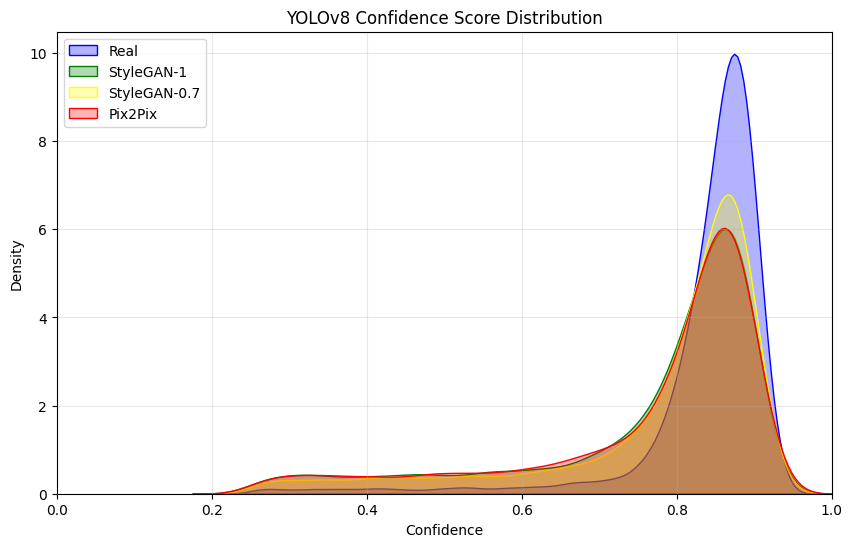

Plot saved in: /kaggle/working/EVAL_IMAGES/confidence_distribution.png


In [9]:
import os
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
from ultralytics import YOLO
from pytorch_fid.fid_score import calculate_fid_given_paths

## Cleaning up VRAM
print("Cleaning up VRAM...")
if 'yolo_model' in globals():
    del yolo_model
torch.cuda.empty_cache()
gc.collect()

YOLO_WEIGHTS_PATH = '/kaggle/working/data/WEIGHTS/YOLOv8m_weights.pt' 
WORK_DIR = '/kaggle/working/EVAL_IMAGES'

PATH_REAL = os.path.join(WORK_DIR, 'eval_real/Reals') 
PATH_STYLEGAN1 = os.path.join(WORK_DIR, 'eval_stylegan_1')
PATH_STYLEGAN07 = os.path.join(WORK_DIR, 'eval_stylegan_07')
PATH_PIX2PIX = os.path.join(WORK_DIR, 'eval_pix2pix')

## YOLO confidence evaluation
yolo_model = YOLO(YOLO_WEIGHTS_PATH)

def evaluate_yolo_confidence_safe(image_dir, model):
    """Executes single-image inference to strictly avoid OOM errors."""
    image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not image_paths:
        print(f"No images found in {image_dir}!")
        return [], 0.0
        
    all_confidences = []
    print(f"Evaluating {len(image_paths)} images in {image_dir}...")
    
    for img_path in image_paths:
        results = model.predict(source=img_path, imgsz=512, save=False, verbose=False)
        for result in results:
            if result.boxes and len(result.boxes) > 0:
                all_confidences.extend(result.boxes.conf.cpu().numpy())
                
    avg_conf = np.mean(all_confidences) if all_confidences else 0.0
    return all_confidences, avg_conf

conf_real, avg_real = evaluate_yolo_confidence_safe(PATH_REAL, yolo_model)
conf_stylegan1, avg_sg1 = evaluate_yolo_confidence_safe(PATH_STYLEGAN1, yolo_model)
conf_stylegan07, avg_sg07 = evaluate_yolo_confidence_safe(PATH_STYLEGAN07, yolo_model)
conf_pix2pix, avg_p2p = evaluate_yolo_confidence_safe(PATH_PIX2PIX, yolo_model)

# Clearing VRAM: removing YOLO before loading InceptionV3 for FID
del yolo_model
torch.cuda.empty_cache()
gc.collect()


## WASSERSTEIN DISTANCE
wd_stylegan1 = wasserstein_distance(conf_real, conf_stylegan1) if conf_stylegan1 else None
wd_stylegan07 = wasserstein_distance(conf_real, conf_stylegan07) if conf_stylegan07 else None
wd_pix2pix = wasserstein_distance(conf_real, conf_pix2pix) if conf_pix2pix else None


## FID SCORE CALCULATION
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def calcola_fid(path_reali, path_finti, nome_gan):
    print(f"Calculating FID for {nome_gan}...")
    try:
        fid_value = calculate_fid_given_paths(
            [path_reali, path_finti],
            batch_size=32, device=device, dims=2048, num_workers=2
        )
        return round(fid_value, 4)
    except Exception as e:
        print(f"FID Error for {nome_gan}: {e}")
        return None

fid_stylegan1 = calcola_fid(PATH_REAL, PATH_STYLEGAN1, "StyleGAN-1")
fid_stylegan07 = calcola_fid(PATH_REAL, PATH_STYLEGAN07, "StyleGAN-0.7")
fid_pix2pix = calcola_fid(PATH_REAL, PATH_PIX2PIX, "Pix2Pix")


## FINAL RESULTS SUMMARY
print("FINAL RESULTS SUMMARY")

results_data = {
    "Architecture": ["Real Images", "StyleGAN (trunc=1.0)", "StyleGAN (trunc=0.7)", "Pix2Pix"],
    "Avg Confidence": [avg_real, avg_sg1, avg_sg07, avg_p2p],
    "Wasserstein Dist.": [0.0, wd_stylegan1, wd_stylegan07, wd_pix2pix],
    "FID Score": [0.0, fid_stylegan1, fid_stylegan07, fid_pix2pix]
}

df_results = pd.DataFrame(results_data)

# Print markdown table for readable terminal/notebook output
print("\n" + df_results.to_markdown(index=False, floatfmt=".4f") + "\n")


## KDE PLOT
plt.figure(figsize=(10, 6))
if len(conf_real) > 0:
    sns.kdeplot(conf_real, label='Real', fill=True, color='blue', alpha=0.3)
if len(conf_stylegan1) > 0:
    sns.kdeplot(conf_stylegan1, label='StyleGAN-1', fill=True, color='green', alpha=0.3)
if len(conf_stylegan07) > 0:
    sns.kdeplot(conf_stylegan07, label='StyleGAN-0.7', fill=True, color='yellow', alpha=0.3)
if len(conf_pix2pix) > 0:
    sns.kdeplot(conf_pix2pix, label='Pix2Pix', fill=True, color='red', alpha=0.3)

plt.title("YOLOv8 Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1.0)
plt.grid(True, alpha=0.3)

plot_path = os.path.join(WORK_DIR, 'confidence_distribution.png')
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Plot saved in: {plot_path}")